In [50]:
%matplotlib ipympl

In [51]:
import matplotlib.pyplot as plt
import numpy as np

### Load Simulation Data

In [52]:
t0 = np.load("../data/fig2/experiment_results.npy", allow_pickle=True).item()
pert = np.load("../data/fig2/relearning_results.npy", allow_pickle=True).item()

In [53]:
og_manifold = pert["manifold"]["original"]["activity2"]
og_trial_order = pert["manifold"]["original"]["order"]
omp_manifold = pert["manifold"]["within"]["activity"].reshape(50, -1, 800)
omp_trial_order = pert["manifold"]["within"]["order"]
wmp_manifold = pert["manifold"]["outside"]["activity"].reshape(50, -1, 800)
wmp_trial_order = pert["manifold"]["outside"]["order"]

In [ ]:
target = 0 # 0-6
neuron_idx = 1

### Neuron Activity Range

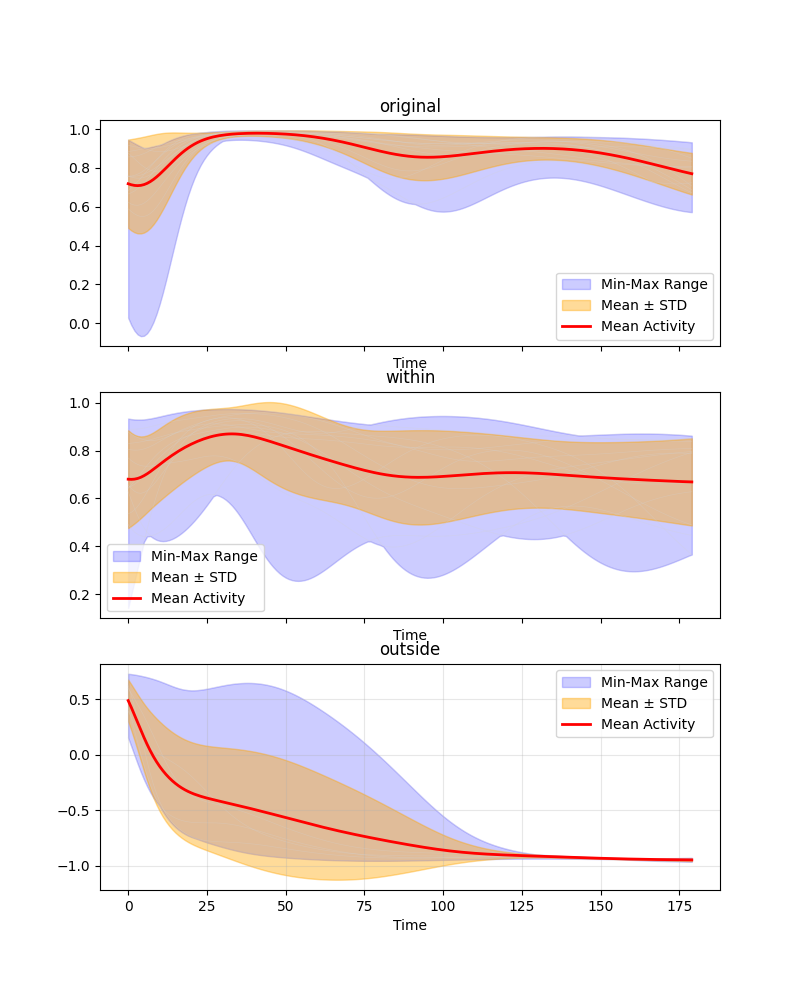

In [70]:
og_activity = og_manifold[og_trial_order == target, :, neuron_idx]
omp_activity = omp_manifold[omp_trial_order == target, :, neuron_idx]
wmp_activity = wmp_manifold[wmp_trial_order == target, :, neuron_idx]

fig, axs = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

timesteps = np.arange(180)
for i, (activity, phase) in enumerate(zip([og_activity, omp_activity, wmp_activity], ["original", "within", "outside"])):
  ax = axs[i]
  ax.set_title(f"{phase}")
  mean_activity = np.mean(activity, axis=0)
  std_activity = np.std(activity, axis=0)
  min_activity = np.min(activity, axis=0)
  max_activity = np.max(activity, axis=0)

  # Plot individual trials (light gray)
  for trial in range(activity.shape[0]):
      ax.plot(timesteps, activity[trial, :], 'lightgray', alpha=0.3, linewidth=0.5)

  # Plot statistics
  ax.fill_between(timesteps, min_activity, max_activity, alpha=0.2, color='blue', label='Min-Max Range')
  ax.fill_between(timesteps, mean_activity - std_activity, mean_activity + std_activity, 
                    alpha=0.4, color='orange', label='Mean ± STD')
  ax.plot(timesteps, mean_activity, 'red', linewidth=2, label='Mean Activity')

  ax.set_xlabel('Time')
  ax.set_label('Neural Activity')
  ax.legend()

plt.grid(True, alpha=0.3)
plt.savefig("../data/fig2/single_neuron_activity.png", dpi=300, bbox_inches='tight')
plt.show()